In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[-6.25795991,  0.14344675],
       [ 5.77555938, 10.03951217],
       [-0.24296915,  5.29460925],
       ...,
       [ 7.0973107 ,  8.27253437],
       [-7.11708169,  0.56131553],
       [-7.16406232,  0.84442125]], shape=(1000, 2))

In [4]:
y

array([0, 2, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 1, 2,
       1, 1, 0, 2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 1, 0, 2, 0, 0, 1, 0,
       2, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 0, 2, 2, 1, 1, 2, 0, 1, 0, 1, 2,
       2, 2, 2, 1, 0, 2, 1, 0, 0, 0, 0, 2, 2, 0, 2, 2, 1, 2, 2, 1, 1, 2,
       1, 1, 1, 0, 2, 2, 2, 0, 0, 1, 2, 2, 2, 2, 1, 1, 2, 1, 0, 0, 2, 1,
       0, 0, 2, 1, 0, 1, 2, 0, 0, 0, 1, 2, 0, 2, 1, 2, 2, 0, 1, 2, 2, 2,
       0, 0, 2, 0, 2, 2, 2, 2, 1, 1, 2, 0, 0, 1, 1, 0, 1, 1, 0, 1, 2, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 2, 0, 1, 1, 0, 1, 2, 0, 1, 1,
       2, 0, 1, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 1, 0, 1, 2, 2, 1, 1, 2, 1,
       2, 2, 1, 2, 2, 2, 1, 1, 2, 1, 2, 2, 0, 0, 0, 1, 2, 2, 0, 1, 1, 1,
       0, 2, 0, 1, 2, 2, 1, 0, 2, 0, 2, 2, 1, 0, 0, 0, 1, 2, 1, 1, 2, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 2, 1, 1, 2, 2, 2, 2, 0, 2,
       0, 0, 2, 1, 1, 1, 1, 0, 2, 0, 2, 1, 1, 0, 2, 0, 0, 0, 1, 0, 0, 2,
       1, 0, 1, 2, 0, 1, 0, 1, 0, 2, 0, 1, 2, 1, 2,

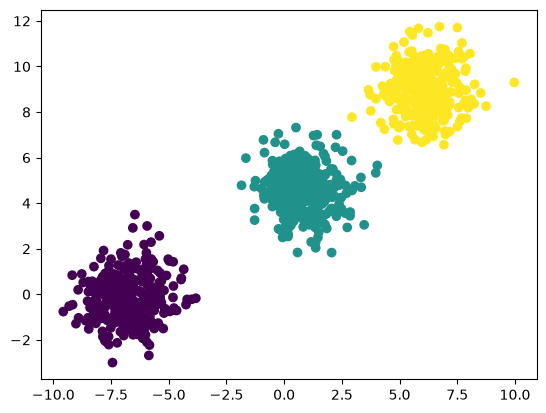

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [9]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans

In [11]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [12]:
wcss

[1340.000000000001,
 338.64687679107476,
 66.69962607184955,
 57.202638981332925,
 48.129464139201076,
 38.47973312919186,
 35.771468797340205,
 32.63829847251475,
 28.575203085908747,
 25.419504673351938]

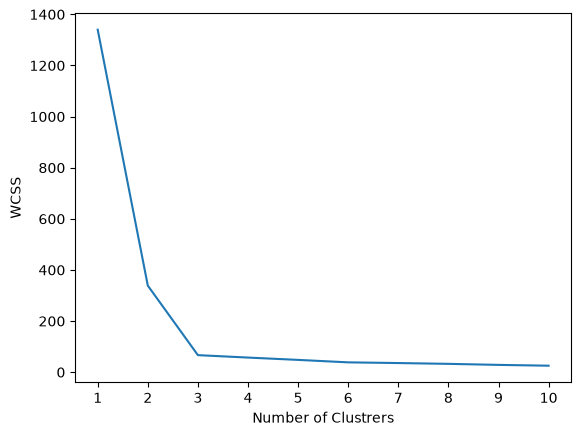

In [13]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [14]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [15]:
kmeans.fit_predict(X_train_scaled)

array([2, 1, 2, 0, 2, 2, 2, 2, 0, 2, 2, 1, 1, 1, 2, 1, 1, 1, 0, 2, 2, 1,
       1, 0, 0, 1, 1, 2, 1, 2, 0, 1, 2, 1, 0, 2, 0, 1, 1, 2, 0, 0, 0, 2,
       2, 1, 0, 2, 1, 0, 0, 0, 2, 2, 2, 0, 1, 2, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 2, 1, 1, 2, 2, 2, 2, 2, 0, 1, 0, 1, 0, 1, 1, 2, 2, 2, 2, 0, 2,
       0, 1, 2, 1, 2, 1, 1, 0, 1, 2, 0, 1, 1, 0, 2, 2, 1, 2, 1, 1, 0, 1,
       0, 0, 0, 2, 1, 2, 1, 1, 1, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       0, 0, 1, 1, 2, 0, 2, 1, 0, 1, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 2, 2,
       0, 2, 0, 0, 2, 0, 0, 0, 2, 1, 2, 0, 2, 1, 2, 2, 1, 2, 1, 0, 1, 2,
       1, 1, 0, 2, 0, 1, 1, 2, 1, 1, 2, 2, 2, 0, 1, 1, 2, 1, 0, 0, 2, 1,
       1, 1, 2, 1, 0, 2, 0, 1, 2, 2, 1, 2, 2, 2, 0, 1, 2, 0, 0, 2, 2, 1,
       1, 1, 1, 1, 0, 2, 2, 0, 2, 2, 0, 2, 0, 0, 1, 0, 2, 2, 2, 1, 0, 0,
       0, 0, 2, 1, 1, 1, 2, 1, 0, 0, 1, 0, 1, 0, 0, 2, 2, 0, 0, 1, 2, 1,
       0, 2, 2, 2, 0, 2, 1, 2, 0, 1, 1, 1, 2, 0, 0, 1, 2, 0, 0, 2, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 2, 0, 1, 1, 2,

In [16]:
y_pred=kmeans.predict(X_test_scaled)

In [17]:
y_pred

array([0, 2, 2, 0, 0, 0, 2, 1, 0, 1, 0, 2, 1, 2, 0, 2, 2, 2, 2, 2, 1, 0,
       0, 1, 2, 2, 1, 2, 2, 0, 0, 1, 0, 0, 2, 1, 1, 2, 1, 0, 2, 2, 2, 2,
       0, 2, 2, 2, 0, 2, 1, 2, 1, 1, 0, 2, 2, 2, 1, 2, 2, 2, 0, 1, 0, 0,
       1, 2, 2, 2, 2, 2, 1, 0, 2, 1, 1, 1, 1, 2, 1, 1, 0, 1, 2, 0, 2, 0,
       1, 1, 0, 1, 2, 0, 2, 1, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1, 2, 0, 2,
       2, 2, 2, 0, 0, 1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 0, 1, 0, 2, 0, 1, 1,
       2, 1, 0, 2, 0, 1, 1, 0, 1, 0, 0, 2, 0, 0, 0, 2, 1, 1, 0, 2, 1, 1,
       0, 0, 2, 0, 1, 2, 1, 2, 0, 1, 0, 1, 1, 0, 0, 2, 0, 0, 2, 1, 0, 0,
       2, 1, 1, 1, 0, 2, 2, 2, 2, 1, 2, 1, 0, 0, 1, 2, 0, 1, 0, 0, 2, 1,
       2, 1, 1, 1, 2, 2, 1, 1, 2, 0, 1, 0, 1, 0, 0, 2, 1, 0, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 1, 2, 1, 0, 0, 2, 1, 2, 2, 1, 1, 1, 2, 2, 0,
       0, 2, 0, 0, 1, 1, 1, 0, 0, 2, 2, 1, 0, 1, 1, 0, 1, 0, 1, 2, 0, 1,
       0, 1, 2, 0, 2, 1, 1, 2, 2, 0, 0, 0, 1, 2, 1, 2, 1, 2, 0, 2, 2, 1,
       0, 2, 2, 2, 1, 0, 2, 0, 2, 2, 2, 1, 2, 2, 2,

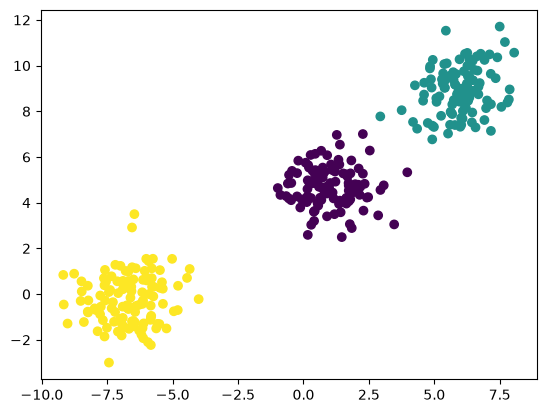

In [18]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [19]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [20]:
## kneelocator
!pip install kneed


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from kneed import KneeLocator

In [22]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [23]:
kl.elbow

np.int64(3)

In [24]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [25]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [26]:
silhouette_coefficients

[0.6698837101015688,
 0.7556836548018613,
 0.6214858645036393,
 0.4770778547813783,
 0.4515173060500285,
 0.4956623154171106,
 0.3558855143639395,
 0.336964990126954,
 0.3509698951456374]

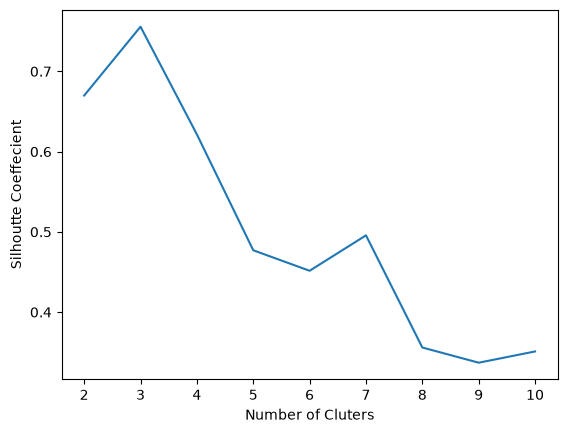

In [27]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()